  WORLD HAPPINESS REPORT — EDA SUMMARY

Shape : (156, 9)

Top 10 Happiest Countries:
    Country  Happiness_Score
    Finland            7.769
    Denmark            7.600
     Norway            7.554
    Iceland            7.494
Netherlands            7.488
Switzerland            7.480
     Sweden            7.343
New Zealand            7.307
     Canada            7.278
    Austria            7.246

Bottom 10 Countries:
                 Country  Happiness_Score
             South Sudan            2.853
Central African Republic            3.083
             Afghanistan            3.203
                Tanzania            3.231
                  Rwanda            3.334
                   Yemen            3.380
                  Malawi            3.410
                   Syria            3.462
                Botswana            3.488
                   Haiti            3.597

Descriptive Stats:
         Rank  Happiness_Score     GDP  Social_Support  Life_Expectancy  \
count  156.00    

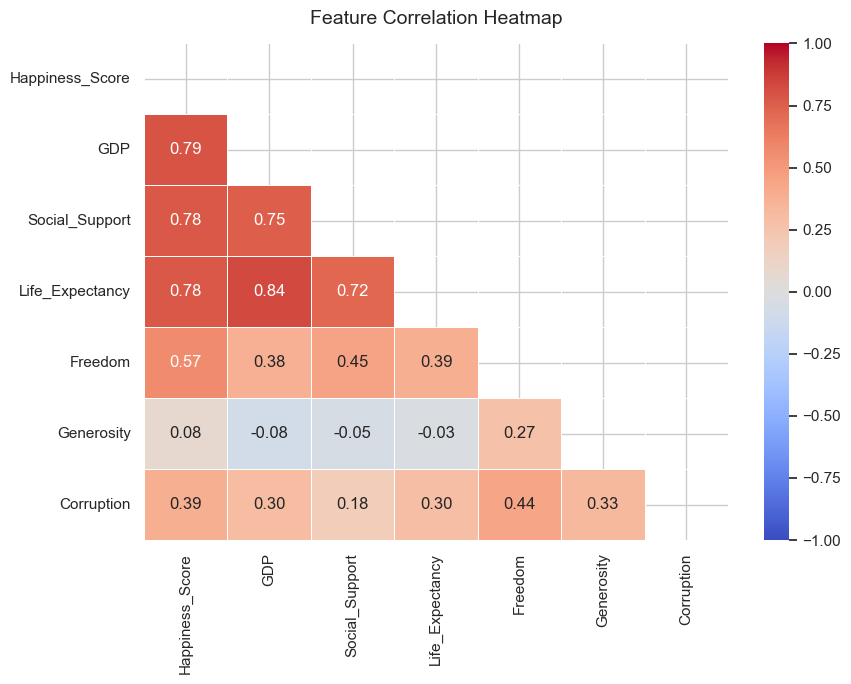

Saved → correlation_heatmap.png


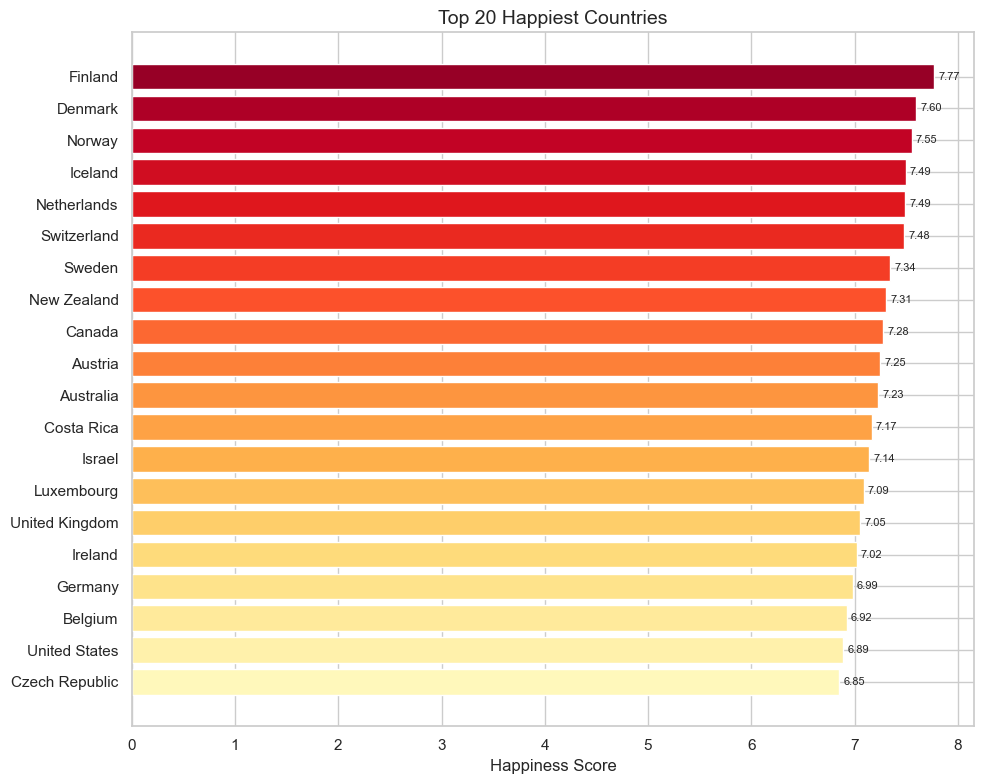

Saved → top_countries.png


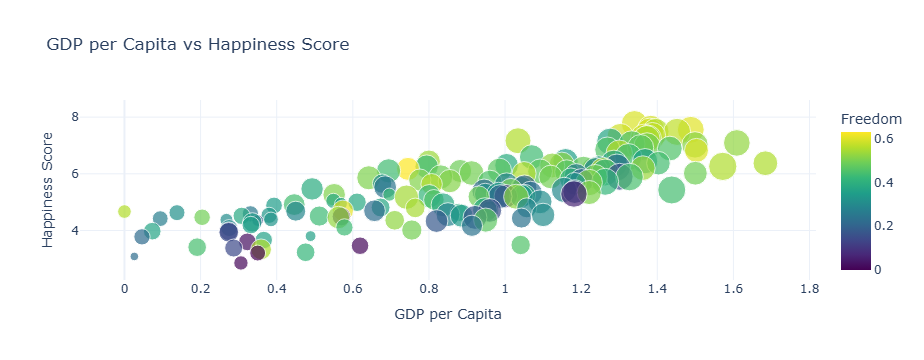

Saved → gdp_vs_happiness.html (interactive)


C:\Users\snikh\AppData\Local\Temp\ipykernel_16124\65990755.py:111: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



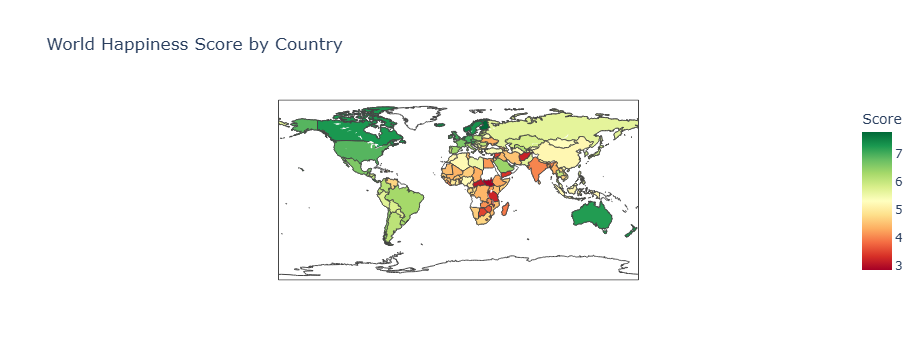

Saved → world_map.html (interactive)


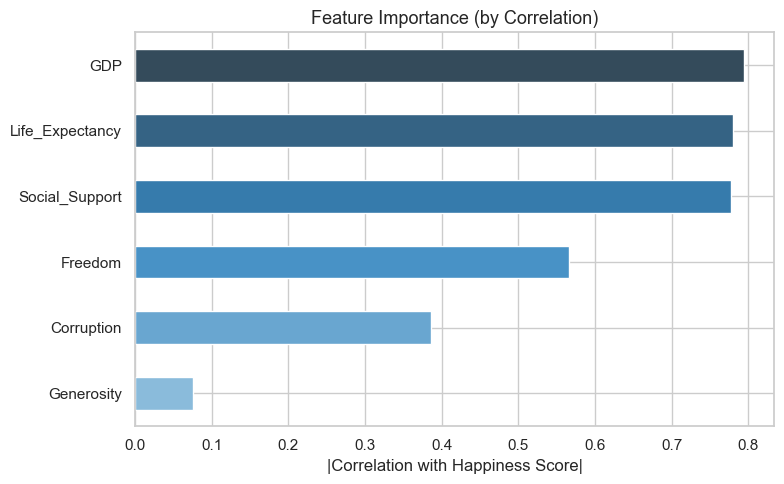

Saved → feature_importance.png


C:\Users\snikh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



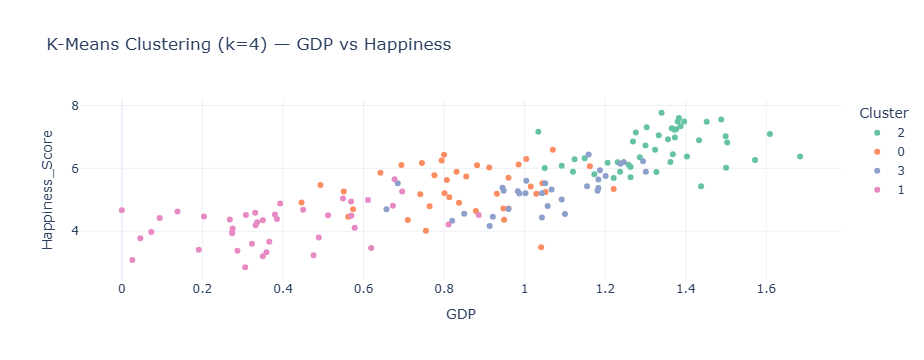

Saved → clusters.html (interactive)

Cluster summary:
         Happiness_Score   GDP  Freedom
Cluster                                
0                   5.36  0.85     0.48
1                   4.20  0.39     0.30
2                   6.64  1.33     0.51
3                   5.28  1.05     0.25

 All analyses complete!


In [3]:
"""
World Happiness Report - Data Analysis Project
================================================
Dataset: https://www.kaggle.com/datasets/unsdsn/world-happiness
Covers reports from 2015–2019 (CSV files per year)

Install dependencies:
    pip install pandas matplotlib seaborn plotly scikit-learn

Usage:
    python happiness_analysis.py
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ── 0. SETTINGS ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
YEAR_FILE = "2019.csv"          # change to whichever year CSV you downloaded

# ── 1. LOAD & CLEAN DATA ─────────────────────────────────────────────────────
def load_data(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath)

    # Standardise column names across report years
    rename_map = {
        "Country or region": "Country",
        "Score": "Happiness_Score",
        "GDP per capita": "GDP",
        "Social support": "Social_Support",
        "Healthy life expectancy": "Life_Expectancy",
        "Freedom to make life choices": "Freedom",
        "Perceptions of corruption": "Corruption",
        "Generosity": "Generosity",
        "Overall rank": "Rank",
    }
    df.rename(columns=rename_map, inplace=True)
    df.dropna(inplace=True)
    return df


# ── 2. EXPLORATORY DATA ANALYSIS ─────────────────────────────────────────────
def run_eda(df: pd.DataFrame):
    print("=" * 55)
    print("  WORLD HAPPINESS REPORT — EDA SUMMARY")
    print("=" * 55)
    print(f"\nShape : {df.shape}")
    print(f"\nTop 10 Happiest Countries:\n{df.nlargest(10, 'Happiness_Score')[['Country','Happiness_Score']].to_string(index=False)}")
    print(f"\nBottom 10 Countries:\n{df.nsmallest(10, 'Happiness_Score')[['Country','Happiness_Score']].to_string(index=False)}")
    print(f"\nDescriptive Stats:\n{df.describe().round(2)}")


# ── 3. CORRELATION HEATMAP ────────────────────────────────────────────────────
def plot_correlation(df: pd.DataFrame):
    features = ["Happiness_Score", "GDP", "Social_Support",
                "Life_Expectancy", "Freedom", "Generosity", "Corruption"]
    corr = df[features].corr()

    fig, ax = plt.subplots(figsize=(9, 7))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
                cmap="coolwarm", linewidths=0.5, ax=ax,
                vmin=-1, vmax=1)
    ax.set_title("Feature Correlation Heatmap", fontsize=14, pad=14)
    plt.tight_layout()
    plt.savefig("correlation_heatmap.png", dpi=150)
    plt.show()
    print("Saved → correlation_heatmap.png")


# ── 4. TOP-N BAR CHART ────────────────────────────────────────────────────────
def plot_top_countries(df: pd.DataFrame, n: int = 20):
    top = df.nlargest(n, "Happiness_Score").sort_values("Happiness_Score")
    colors = sns.color_palette("YlOrRd", n)

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(top["Country"], top["Happiness_Score"], color=colors)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    ax.set_xlabel("Happiness Score")
    ax.set_title(f"Top {n} Happiest Countries", fontsize=14)
    plt.tight_layout()
    plt.savefig("top_countries.png", dpi=150)
    plt.show()
    print("Saved → top_countries.png")


# ── 5. SCATTER: GDP vs HAPPINESS ──────────────────────────────────────────────
def plot_gdp_vs_happiness(df: pd.DataFrame):
    fig = px.scatter(
        df, x="GDP", y="Happiness_Score",
        size="Life_Expectancy", color="Freedom",
        hover_name="Country",
        color_continuous_scale="Viridis",
        title="GDP per Capita vs Happiness Score",
        labels={"GDP": "GDP per Capita", "Happiness_Score": "Happiness Score"},
        template="plotly_white",
    )
    fig.write_html("gdp_vs_happiness.html")
    fig.show()
    print("Saved → gdp_vs_happiness.html (interactive)")


# ── 6. WORLD MAP ──────────────────────────────────────────────────────────────
def plot_world_map(df: pd.DataFrame):
    fig = px.choropleth(
        df, locations="Country", locationmode="country names",
        color="Happiness_Score",
        color_continuous_scale="RdYlGn",
        title="World Happiness Score by Country",
        template="plotly_white",
    )
    fig.update_layout(coloraxis_colorbar_title="Score")
    fig.write_html("world_map.html")
    fig.show()
    print("Saved → world_map.html (interactive)")


# ── 7. FEATURE IMPORTANCE (correlation with score) ───────────────────────────
def plot_feature_importance(df: pd.DataFrame):
    features = ["GDP", "Social_Support", "Life_Expectancy",
                "Freedom", "Generosity", "Corruption"]
    importances = df[features].corrwith(df["Happiness_Score"]).abs().sort_values()

    fig, ax = plt.subplots(figsize=(8, 5))
    importances.plot(kind="barh", ax=ax,
                     color=sns.color_palette("Blues_d", len(features)))
    ax.set_xlabel("|Correlation with Happiness Score|")
    ax.set_title("Feature Importance (by Correlation)", fontsize=13)
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150)
    plt.show()
    print("Saved → feature_importance.png")


# ── 8. K-MEANS CLUSTERING ─────────────────────────────────────────────────────
def cluster_countries(df: pd.DataFrame, k: int = 4):
    features = ["GDP", "Social_Support", "Life_Expectancy", "Freedom"]
    scaler = StandardScaler()
    X = scaler.fit_transform(df[features])

    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    df = df.copy()
    df["Cluster"] = km.fit_predict(X).astype(str)

    fig = px.scatter(
        df, x="GDP", y="Happiness_Score",
        color="Cluster", hover_name="Country",
        title=f"K-Means Clustering (k={k}) — GDP vs Happiness",
        template="plotly_white",
        color_discrete_sequence=px.colors.qualitative.Set2,
    )
    fig.write_html("clusters.html")
    fig.show()
    print("Saved → clusters.html (interactive)")

    print("\nCluster summary:")
    print(df.groupby("Cluster")[["Happiness_Score", "GDP", "Freedom"]].mean().round(2))


# ── MAIN ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    df = load_data(YEAR_FILE)
    run_eda(df)
    plot_correlation(df)
    plot_top_countries(df)
    plot_gdp_vs_happiness(df)
    plot_world_map(df)
    plot_feature_importance(df)
    cluster_countries(df)
    print("\n All analyses complete!")